# Cross-State Real Estate EDA

This notebook explores a family of Kaggle real-estate datasets posted by `Kanchana1990`. The goal is to understand whether the datasets are consistent enough to combine into one NLP-friendly corpus and to identify the quality issues we should clean before modeling.

## Questions this notebook answers

- Which states are currently in the collection?
- Do the datasets share a common schema?
- Which columns are sparse or state-specific?
- How usable are the listing descriptions for NLP work?
- Are there duplicate rows or repeated descriptions?
- What cleaning and unification work should happen next?

In [1]:
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

mpl_config_dir = PROJECT_ROOT / '.matplotlib'
mpl_config_dir.mkdir(exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(mpl_config_dir)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 160)
sns.set_theme(style='whitegrid')

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
RAW_DIR

WindowsPath('c:/Users/rjpet/OneDrive/Desktop/coding_project/nlp_real_estate/data/raw')

In [2]:
DATASET_LABELS = {
    'wisconsin-real-estate-data-2026': 'Wisconsin',
    'connecticut-real-estate-data-2026': 'Connecticut',
    'real-estate-data-oregon-2026': 'Oregon',
    'new-york-real-estate-data-2026': 'New York',
    'new-hampshire-real-estate-data-2026': 'New Hampshire',
    'indiana-real-estate-data-2026': 'Indiana',
    'kentucky-real-estate-data-2026': 'Kentucky',
    'colorado-real-estate-market-2026': 'Colorado',
}


def load_state_frames(raw_dir: Path) -> dict[str, pd.DataFrame]:
    frames = {}
    for csv_path in sorted(raw_dir.rglob('*.csv')):
        dataset_folder = csv_path.parent.name
        state = DATASET_LABELS.get(dataset_folder, dataset_folder)
        frame = pd.read_csv(csv_path)
        frame['state'] = state
        frame['source_dataset'] = dataset_folder
        frame['source_file'] = csv_path.name
        frames[state] = frame
    return frames


state_frames = load_state_frames(RAW_DIR)
sorted(state_frames)

['Colorado',
 'Connecticut',
 'Indiana',
 'Kentucky',
 'New Hampshire',
 'New York',
 'Oregon',
 'Wisconsin']

## Inventory of the downloaded collection

In [3]:
inventory_rows = []
for state, df in state_frames.items():
    inventory_rows.append({
        'state': state,
        'rows': len(df),
        'columns': len(df.columns),
        'source_file': df['source_file'].iloc[0],
    })

inventory = pd.DataFrame(inventory_rows).sort_values('rows', ascending=False)
inventory

,state,rows,columns,source_file
2,Indiana,13532,15,indiana_real_estate_2026.csv
7,Wisconsin,12643,15,wisconsin_real_estate_data_2026.csv
6,Oregon,10403,15,oregon_real_estate_2026_ultimate.csv
1,Connecticut,8701,15,connecticut_real_estate_2026.csv
3,Kentucky,8502,15,kentucky_real_estate.csv
0,Colorado,8362,14,colorado_real_estate_2026.csv
5,New York,8273,14,new_york_real_estate_2026_final.csv
4,New Hampshire,5009,14,new_hampshire_real_estate_2026.csv


C:\Users\rjpet\AppData\Local\Temp\ipykernel_12384\669733549.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inventory, x='rows', y='state', palette='crest', ax=ax)


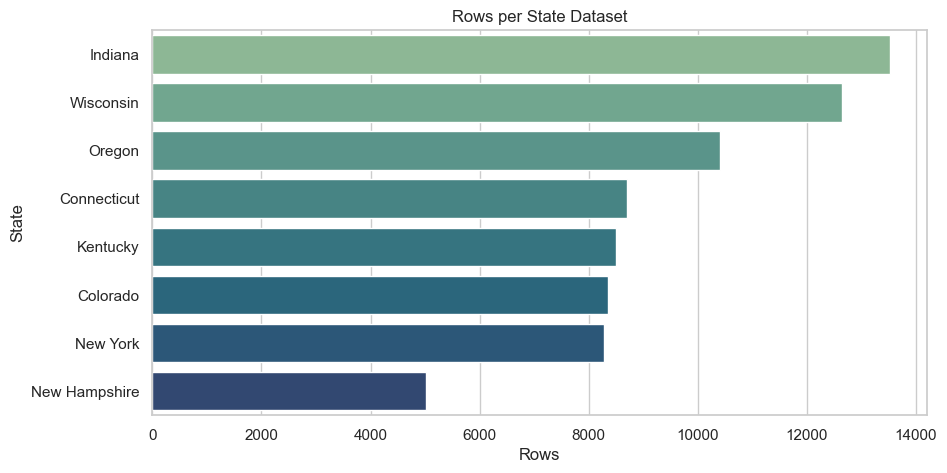

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=inventory, x='rows', y='state', palette='crest', ax=ax)
ax.set_title('Rows per State Dataset')
ax.set_xlabel('Rows')
ax.set_ylabel('State')
plt.show()

## Schema comparison

The first pass question is whether these files are actually compatible. The answer looks promising: all states share the same core structure, and the only systematic schema difference is that `year_built` appears in some states but not others.

In [5]:
schema_rows = []
for state, df in state_frames.items():
    row = {'state': state}
    for col in sorted(set().union(*[set(frame.columns) for frame in state_frames.values()])):
        row[col] = col in df.columns
    schema_rows.append(row)

schema_matrix = pd.DataFrame(schema_rows).sort_values('state').set_index('state')
schema_matrix

,baths,baths_full,baths_full_calc,beds,garage,listPrice,source_dataset,source_file,sqft,stories,sub_type,text,type,year_built
state,,,,,,,,,,,,,,
True,True,True,True,True,True,True,True,True,True,True,True,True,True,False
True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
True,True,True,True,True,True,True,True,True,True,True,True,True,True,False
True,True,True,True,True,True,True,True,True,True,True,True,True,True,False
True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [6]:
combined = pd.concat(state_frames.values(), ignore_index=True, sort=False)
combined.shape

(75425, 15)

## Missingness by state

This is where the future cleaning pipeline will focus. Several columns have meaningful missingness, especially `sub_type`, `stories`, `garage`, and some numerical home attributes. `year_built` is absent in the states where the column was never provided.

In [7]:
missingness = []
for state, df in state_frames.items():
    row = {'state': state}
    for col in ['type', 'sub_type', 'text', 'listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built']:
        if col in df.columns:
            row[col] = round(df[col].isna().mean() * 100, 1)
        else:
            row[col] = None
    missingness.append(row)

missingness_df = pd.DataFrame(missingness).sort_values('state')
missingness_df

,state,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
0,Colorado,0.0,81.3,0.5,0.0,28.5,45.7,28.3,15.3,31.0,28.6,45.7,NaN
1,Connecticut,0.0,79.9,0.1,0.0,9.8,79.6,9.9,10.4,10.1,10.1,41.8,10.4
2,Indiana,0.0,93.9,1.1,0.0,19.3,21.8,18.8,23.1,19.3,19.1,32.0,28.5
3,Kentucky,0.0,93.7,1.4,0.2,7.5,21.1,4.8,8.2,5.9,5.9,34.1,20.7
4,New Hampshire,0.0,78.8,0.2,0.0,21.5,26.2,22.8,23.2,26.9,23.4,51.1,NaN
5,New York,0.0,77.1,0.0,0.0,13.4,50.5,4.1,4.7,5.2,5.1,50.9,NaN
6,Oregon,0.0,87.1,0.2,0.0,20.0,21.3,19.9,19.2,20.1,20.1,36.2,22.7
7,Wisconsin,0.0,89.4,0.5,0.0,31.6,51.8,29.3,26.0,30.1,29.8,40.5,31.9


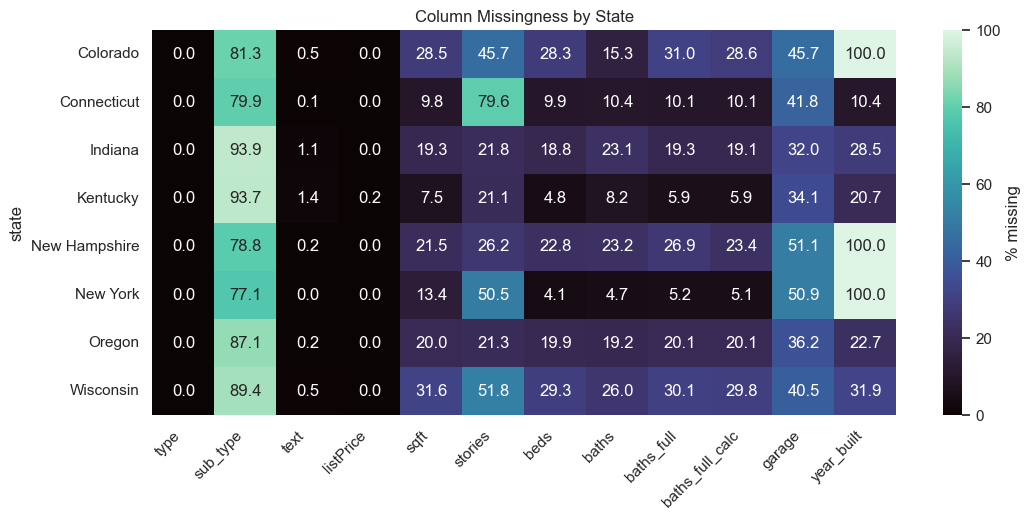

In [8]:
heatmap_df = missingness_df.set_index('state').fillna(100)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heatmap_df, cmap='mako', annot=True, fmt='.1f', cbar_kws={'label': '% missing'}, ax=ax)
ax.set_title('Column Missingness by State')
plt.xticks(rotation=45, ha='right')
plt.show()

## Listing text quality and NLP readiness

The `text` field is the core NLP asset here, so we want to know how rich it is, how often it is missing, and whether any states contain weak boilerplate descriptions.

In [9]:
def text_profile(df: pd.DataFrame) -> dict:
    text = df['text'].fillna('').astype(str).str.strip()
    return {
        'missing_text': int(df['text'].isna().sum()),
        'blank_text': int(text.eq('').sum()),
        'short_lt_40_chars': int((text.str.len() < 40).sum()),
        'median_text_len': int(text.str.len().median()),
        'avg_text_len': round(text.str.len().mean(), 1),
        'p90_text_len': int(text.str.len().quantile(0.9)),
        'long_gt_2000_chars': int((text.str.len() > 2000).sum()),
        'placeholder_descriptions': int(text.str.lower().isin(['no description provided.', 'shortsale.']).sum()),
    }


text_profiles = pd.DataFrame([
    {'state': state, **text_profile(df)}
    for state, df in state_frames.items()
]).sort_values('avg_text_len', ascending=False)
text_profiles

,state,missing_text,blank_text,short_lt_40_chars,median_text_len,avg_text_len,p90_text_len,long_gt_2000_chars,placeholder_descriptions
0,Colorado,39,39,42,1036,1102.9,1897,189,0
5,New York,0,0,87,970,1092.0,1980,788,44
4,New Hampshire,11,11,14,1025,1032.4,1550,2,0
1,Connecticut,6,6,32,948,937.5,1476,48,0
6,Oregon,19,19,35,808,872.7,1550,67,0
2,Indiana,150,150,227,815,863.1,1495,140,0
3,Kentucky,122,122,148,756,842.5,1456,263,0
7,Wisconsin,60,60,80,677,665.7,969,92,0


C:\Users\rjpet\AppData\Local\Temp\ipykernel_12384\481811916.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=text_profiles, x='avg_text_len', y='state', palette='flare', ax=axes[0])
C:\Users\rjpet\AppData\Local\Temp\ipykernel_12384\481811916.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=text_profiles, x='placeholder_descriptions', y='state', palette='rocket', ax=axes[1])


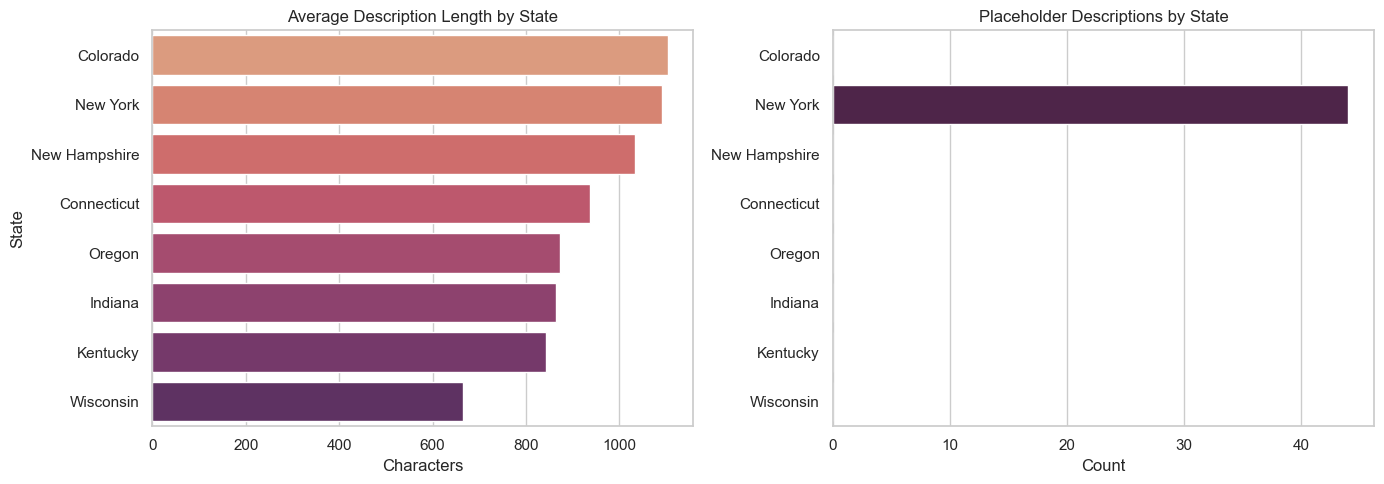

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=text_profiles, x='avg_text_len', y='state', palette='flare', ax=axes[0])
axes[0].set_title('Average Description Length by State')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('State')

sns.barplot(data=text_profiles, x='placeholder_descriptions', y='state', palette='rocket', ax=axes[1])
axes[1].set_title('Placeholder Descriptions by State')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [11]:
ny = state_frames['New York']
ny_placeholders = ny[ny['text'].fillna('').astype(str).str.strip().str.lower().isin(['no description provided.', 'shortsale.'])]
ny_placeholders[['type', 'sub_type', 'text', 'listPrice', 'beds', 'baths']].head(10)

,type,sub_type,text,listPrice,beds,baths
0,single_family,NaN,No description provided.,325000.0,3.0,2.0
1,single_family,NaN,Shortsale.,308000.0,4.0,4.0
110,single_family,NaN,No description provided.,300000.0,4.0,3.0
212,single_family,NaN,No description provided.,150000.0,3.0,3.0
304,single_family,NaN,No description provided.,189900.0,3.0,2.0
422,single_family,NaN,No description provided.,450000.0,5.0,3.0
758,single_family,NaN,No description provided.,190000.0,4.0,2.0
1092,single_family,NaN,No description provided.,55000.0,2.0,1.0
1306,multi_family,NaN,No description provided.,65000.0,6.0,3.0
1439,single_family,NaN,No description provided.,1245000.0,4.0,3.0


## Repeated content and possible duplicate listings

A model-ready corpus should not be full of repeated marketing copy. The next table separates exact row duplicates from repeated `text` values. Repeated descriptions are not always wrong, but they are worth auditing because they can bias token counts and downstream evaluation.

In [12]:
duplicate_profile = []
for state, df in state_frames.items():
    text = df['text'].fillna('').astype(str).str.strip()
    duplicate_profile.append({
        'state': state,
        'duplicate_full_rows': int(df.duplicated().sum()),
        'duplicate_text_rows': int(text.duplicated().sum()),
        'duplicate_text_pct': round(text.duplicated().mean() * 100, 2),
    })

duplicate_df = pd.DataFrame(duplicate_profile).sort_values('duplicate_text_rows', ascending=False)
duplicate_df

,state,duplicate_full_rows,duplicate_text_rows,duplicate_text_pct
2,Indiana,10,854,6.31
7,Wisconsin,8,689,5.45
3,Kentucky,49,459,5.40
4,New Hampshire,80,196,3.91
0,Colorado,0,174,2.08
6,Oregon,0,150,1.44
1,Connecticut,1,83,0.95
5,New York,0,64,0.77


In [13]:
kentucky = state_frames['Kentucky']
kentucky[kentucky.duplicated(keep=False)].head(6)

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,state,source_dataset,source_file
10,townhomes,townhouse,"Directly across from Maples Park in Crestwood, this townhome is not only convenient to amenities, but it is priced to sell quickly. Be a part of the launch ...",399900.0,1734.0,3.0,3.0,4.0,2.0,2.0,1.0,2025.0,Kentucky,kentucky-real-estate-data-2026,kentucky_real_estate.csv
69,townhomes,townhouse,"Welcome to the highly sought-after, upscale neighborhood...The Village Walk at Robinbrooke Farms! This property, located in Elizabethtown, Ky, offers a uniq...",349000.0,2027.0,NaN,3.0,3.0,2.0,2.0,1.0,2025.0,Kentucky,kentucky-real-estate-data-2026,kentucky_real_estate.csv
206,condos,condo,Welcome to Henderson Kentucky's newest 55+ Condominium community. The Condo's of Copper Creek are designed to make living simple! These beautiful condominiu...,295000.0,1154.0,NaN,2.0,2.0,2.0,2.0,1.0,2024.0,Kentucky,kentucky-real-estate-data-2026,kentucky_real_estate.csv
245,condos,condo,New construction and move-in ready at Brookley Place! Be the first to own this beautifully finished home designed with today's lifestyle in mind. Step insid...,238500.0,1260.0,1.0,2.0,2.0,2.0,2.0,1.0,2025.0,Kentucky,kentucky-real-estate-data-2026,kentucky_real_estate.csv
250,multi_family,NaN,"Turnkey brick duplex offering two identical 3-bedroom, 2.5-bath units with strong rental appeal. Each unit features an open-concept kitchen and living area ...",349000.0,NaN,NaN,6.0,6.0,4.0,4.0,NaN,2026.0,Kentucky,kentucky-real-estate-data-2026,kentucky_real_estate.csv
398,townhomes,townhouse,New construction 3 bed 2.5 bath townhouse with an office/bonus room. Great location! Beautiful inside with lots of space! Adjoining town home can be purchas...,266500.0,1778.0,NaN,3.0,3.0,2.0,2.0,1.0,2026.0,Kentucky,kentucky-real-estate-data-2026,kentucky_real_estate.csv


## Numeric field overview

Before cleaning, it helps to understand the magnitude and range of the core structured features. We are not doing outlier cleaning yet, but we can already see where unusual values are likely to require review.

In [14]:
numeric_summary_rows = []
for state, df in state_frames.items():
    price = pd.to_numeric(df['listPrice'], errors='coerce')
    sqft = pd.to_numeric(df['sqft'], errors='coerce')
    numeric_summary_rows.append({
        'state': state,
        'min_price': price.min(),
        'median_price': price.median(),
        'max_price': price.max(),
        'median_sqft': sqft.median(),
        'missing_sqft_pct': round(sqft.isna().mean() * 100, 1),
    })

numeric_summary = pd.DataFrame(numeric_summary_rows).sort_values('median_price', ascending=False)
numeric_summary

,state,min_price,median_price,max_price,median_sqft,missing_sqft_pct
5,New York,1.0,529900.0,80000000.0,1680.0,13.4
6,Oregon,1.0,495000.0,54580000.0,1824.0,20.0
0,Colorado,1.0,491990.5,45000000.0,1962.0,28.5
4,New Hampshire,450.0,459000.0,16950000.0,1789.0,21.5
1,Connecticut,4000.0,449900.0,75000000.0,1883.0,9.8
3,Kentucky,1.0,317900.0,20000000.0,1850.0,7.5
7,Wisconsin,1.0,309900.0,23250000.0,1776.0,31.6
2,Indiana,1.0,295000.0,47900000.0,1853.0,19.3


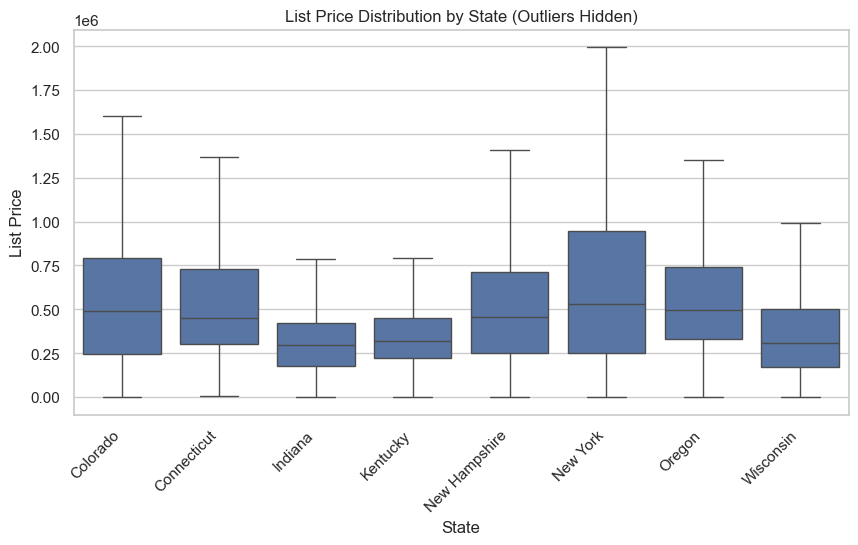

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=combined, x='state', y='listPrice', showfliers=False, ax=ax)
ax.set_title('List Price Distribution by State (Outliers Hidden)')
ax.set_ylabel('List Price')
ax.set_xlabel('State')
plt.xticks(rotation=45, ha='right')
plt.show()

## Categorical structure

These datasets mix structured home attributes with listing text, so it helps to understand the categorical spread of `type` and the sparsity of `sub_type`.

In [16]:
type_mix = (
    combined.groupby(['state', 'type'])
    .size()
    .reset_index(name='count')
    .sort_values(['state', 'count'], ascending=[True, False])
)
type_mix.head(20)

,state,type,count
7,Colorado,single_family,3936
4,Colorado,land,2279
1,Colorado,condos,980
8,Colorado,townhomes,643
5,Colorado,mobile,245
6,Colorado,multi_family,152
3,Colorado,farm,100
2,Colorado,duplex_triplex,26
0,Colorado,apartment,1
14,Connecticut,single_family,5054


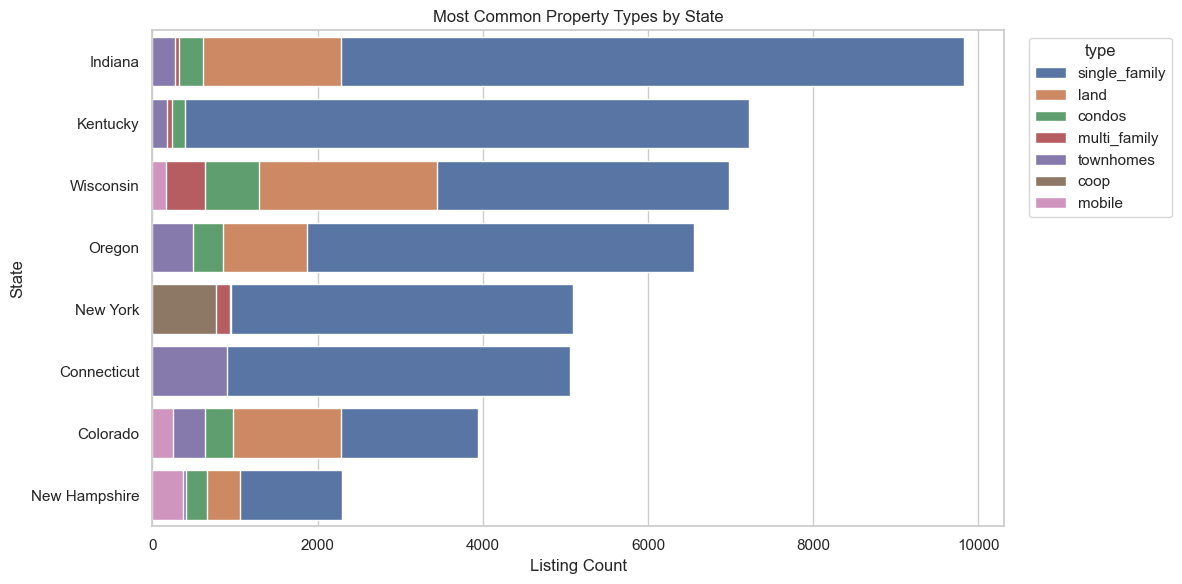

In [17]:
top_types = (
    type_mix.sort_values('count', ascending=False)
    .groupby('state')
    .head(5)
)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_types, x='count', y='state', hue='type', dodge=False, ax=ax)
ax.set_title('Most Common Property Types by State')
ax.set_xlabel('Listing Count')
ax.set_ylabel('State')
ax.legend(title='type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## NLP-focused takeaways

This dataset family looks very workable for text analysis.

Strengths:
- All states include a free-text description field.
- The core structured schema is highly consistent.
- The combined corpus is large enough for descriptive NLP, embeddings, topic work, retrieval, or supervised experiments.

Risks to handle in cleaning:
- Placeholder or weak descriptions, especially in New York.
- Repeated descriptions and some exact duplicate rows.
- Missing `sub_type`, `stories`, `garage`, and state-specific `year_built` coverage.
- Some extreme numeric values that deserve validation before modeling.

## Recommended next step

Build a cleaning and unification pipeline that:

1. standardizes schema across all states
2. adds a canonical `state` field
3. flags placeholder descriptions and duplicate text
4. normalizes numeric columns and missing markers
5. writes one combined modeling table plus a QA report